# 05 · Comparação: KNN vs. Modelos Lineares

Fecha o Dia 1 comparando os modelos baseados em distância (KNN majoritário e ponderado) contra os modelos lineares clássicos (Regressão Logística / Regressão Linear), em múltiplos datasets — o mesmo espírito da metodologia usada no pôster do CIC (vários datasets, validação cruzada).

A estrutura é **genérica de propósito**: os modelos ficam num dicionário, e o loop de avaliação não sabe (nem precisa saber) o que tem dentro de cada modelo. Isso significa que adicionar o FEMa depois é literalmente uma linha: `"FEMa": FEMaClassifier()`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from distance_models import KNNClassifier, KNNRegressor
from datasets_utils import load_classification_dataset, load_regression_dataset
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import cross_validate

plt.rcParams['figure.facecolor'] = 'white'

## 1. Classificação: 3 datasets x 3 modelos

Mesmos datasets do pôster (Breast Cancer, Digits, Iris) — mas aqui como *demonstração pedagógica* de metodologia, não como o estudo final (esse já foi feito, com FEMa, no pôster).

In [2]:
modelos_clf = {
    'KNN majoritário': KNNClassifier(k=7, weighting='majority'),
    'KNN ponderado':   KNNClassifier(k=7, weighting='distance'),
    'Regressão Logística': LogisticRegression(max_iter=2000),
    # 'FEMa': FEMaClassifier(...),   <- quando existir, só descomentar esta linha
}

datasets_clf = ['breast_cancer', 'digits', 'iris']
scoring = ['accuracy', 'balanced_accuracy', 'f1_macro']

linhas = []
for ds_name in datasets_clf:
    X_train, X_test, y_train, y_test, _ = load_classification_dataset(ds_name)
    for nome_modelo, modelo in modelos_clf.items():
        cv_result = cross_validate(modelo, X_train, y_train, cv=10, scoring=scoring)
        linhas.append({
            'Dataset': ds_name,
            'Modelo': nome_modelo,
            'Acurácia': cv_result['test_accuracy'].mean(),
            'Acurácia balanceada': cv_result['test_balanced_accuracy'].mean(),
            'F1 (macro)': cv_result['test_f1_macro'].mean(),
        })

tabela_clf = pd.DataFrame(linhas).round(4)
tabela_clf

,Dataset,Modelo,Acurácia,Acurácia balanceada,F1 (macro)
0,breast_cancer,KNN majoritário,0.9649,0.9607,0.9619
1,breast_cancer,KNN ponderado,0.9649,0.9607,0.9619
2,breast_cancer,Regressão Logística,0.9799,0.9758,0.9783
3,digits,KNN majoritário,0.9713,0.9707,0.9703
4,digits,KNN ponderado,0.9729,0.9729,0.9721
5,digits,Regressão Logística,0.9642,0.9642,0.9638
6,iris,KNN majoritário,0.9618,0.9694,0.9577
7,iris,KNN ponderado,0.9618,0.9694,0.9577
8,iris,Regressão Logística,0.9818,0.9833,0.9831


### Visualizando: F1-score por dataset e modelo

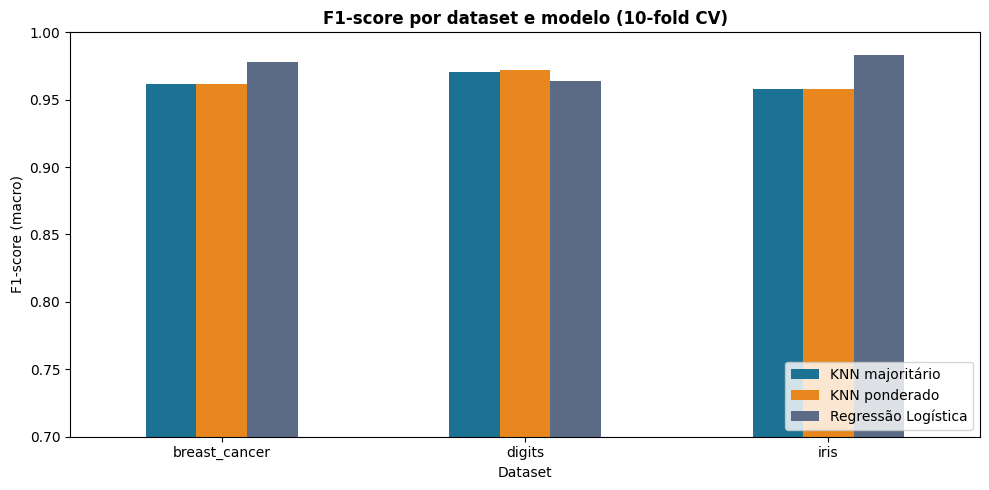

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
pivot = tabela_clf.pivot(index='Dataset', columns='Modelo', values='F1 (macro)')
pivot.plot(kind='bar', ax=ax, color=['#1C7293', '#E8871E', '#5B6B85', '#D64550'][:len(modelos_clf)])
ax.set_ylabel('F1-score (macro)')
ax.set_ylim(0.7, 1.0)
ax.set_title('F1-score por dataset e modelo (10-fold CV)', fontweight='bold')
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## 2. Regressão: 2 datasets x 3 modelos

In [4]:
modelos_reg = {
    'KNN majoritário': KNNRegressor(k=9, weighting='majority'),
    'KNN ponderado':   KNNRegressor(k=9, weighting='distance'),
    'Regressão Linear': LinearRegression(),
    # 'FEMa': FEMaRegressor(...),   <- quando existir, só descomentar esta linha
}

datasets_reg = ['diabetes', 'synthetic_nonlinear']  # 2o dataset é sintético (sem downloads); ver docstring em datasets_utils.py
scoring_reg = ['neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2']

linhas_reg = []
for ds_name in datasets_reg:
    X_train, X_test, y_train, y_test = load_regression_dataset(ds_name)
    for nome_modelo, modelo in modelos_reg.items():
        cv_result = cross_validate(modelo, X_train, y_train, cv=5, scoring=scoring_reg)
        linhas_reg.append({
            'Dataset': ds_name,
            'Modelo': nome_modelo,
            'MAE': -cv_result['test_neg_mean_absolute_error'].mean(),
            'RMSE': -cv_result['test_neg_root_mean_squared_error'].mean(),
            'R²': cv_result['test_r2'].mean(),
        })

tabela_reg = pd.DataFrame(linhas_reg).round(4)
tabela_reg

,Dataset,Modelo,MAE,RMSE,R²
0,diabetes,KNN majoritário,49.1334,60.5231,0.3718
1,diabetes,KNN ponderado,48.7578,60.3305,0.3759
2,diabetes,Regressão Linear,45.5808,56.2432,0.4523
3,synthetic_nonlinear,KNN majoritário,31.2599,40.8055,0.8399
4,synthetic_nonlinear,KNN ponderado,30.3558,39.9328,0.8467
5,synthetic_nonlinear,Regressão Linear,9.0287,11.9330,0.9861


### Visualizando: R² por dataset e modelo

`synthetic_nonlinear` tem uma relação não-linear proposital entre X e y — repare como isso muda o desempenho relativo do KNN frente à Regressão Linear, comparado ao dataset diabetes (mais próximo de linear).

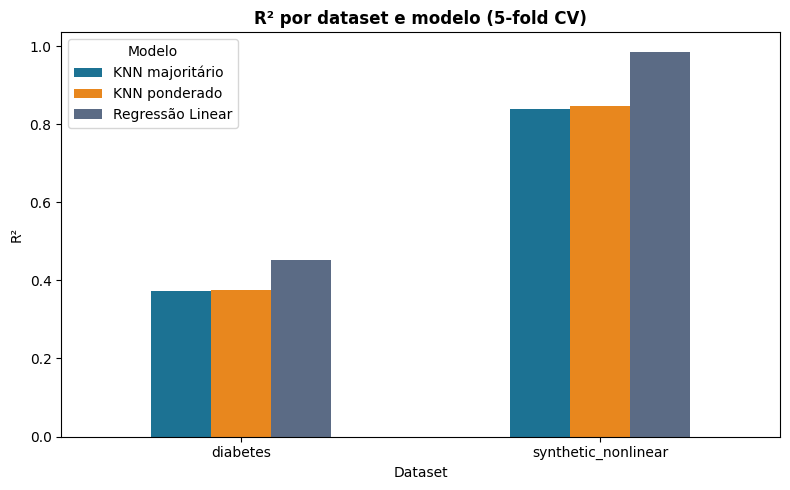

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
pivot_r2 = tabela_reg.pivot(index='Dataset', columns='Modelo', values='R²')
pivot_r2.plot(kind='bar', ax=ax, color=['#1C7293', '#E8871E', '#5B6B85'])
ax.set_ylabel('R²')
ax.set_title('R² por dataset e modelo (5-fold CV)', fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## 3. O que essa comparação já deixa pronto para o FEMa

- **Os dicionários `modelos_clf` / `modelos_reg`** já têm a linha comentada exata onde o FEMa entra.
- **O loop de avaliação** (`cross_validate`) não muda nada — funciona com qualquer estimator no padrão scikit-learn.
- **As tabelas e gráficos** são gerados a partir do mesmo DataFrame — plugar o FEMa só adiciona uma linha/barra a mais, automaticamente.
- O próximo passo natural (Dia 2) é: implementar `FEMaClassifier`/`FEMaRegressor` em `src/distance_models.py` (esqueleto já deixado lá), rodar exatamente este notebook de novo, e comparar diretamente com os testes estatísticos (Friedman/Wilcoxon/Holm) do pôster do CIC.